In [1]:
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

round_order = ['R7', 'R8', 'R9']
round_colors = {'R7': '#475569', 'R8': '#0f766e', 'R9': '#b45309'}
survey_csv_paths = {
    'R7': Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R7.csv'),
    'R8': Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R8.csv'),
    'R9': Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R9.csv'),
}
analysis_inference_dir = Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/inference')

survey_country_map = {
    'ANG': 'Angola',
    'BEN': 'Benin',
    'BFO': 'Burkina Faso',
    'BOT': 'Botswana',
    'CAM': 'Cameroon',
    'CBZ': 'Congo',
    'CDI': "Cote d'Ivoire",
    'CVE': 'Cabo Verde',
    'ESW': 'eSwatini',
    'ETH': 'Ethiopia',
    'GAB': 'Gabon',
    'GAM': 'Gambia',
    'GHA': 'Ghana',
    'GUI': 'Guinea',
    'KEN': 'Kenya',
    'LES': 'Lesotho',
    'LIB': 'Liberia',
    'MAD': 'Madagascar',
    'MAU': 'Mauritius',
    'MLI': 'Mali',
    'MLW': 'Malawi',
    'MOR': 'Morocco',
    'MOZ': 'Mozambique',
    'MTA': 'Mauritania',
    'NAM': 'Namibia',
    'NGR': 'Niger',
    'NIG': 'Nigeria',
    'SAF': 'South Africa',
    'SEN': 'Senegal',
    'SEY': 'Seychelles',
    'SRL': 'Sierra Leone',
    'STP': 'Sao Tome and Principe',
    'SUD': 'Sudan',
    'SWZ': 'eSwatini',
    'TAN': 'Tanzania',
    'TOG': 'Togo',
    'TUN': 'Tunisia',
    'UGA': 'Uganda',
    'ZAM': 'Zambia',
    'ZIM': 'Zimbabwe',
}
urbanicity_map = {1.0: 'Urban', 2.0: 'Rural'}
country_aliases = {
    "Cote d'Ivoire": "Cote d'Ivoire",
    'Eq. Guinea': 'Equatorial Guinea',
    'Dem. Rep. Congo': 'Democratic Republic of the Congo',
    'Central African Rep.': 'Central African Republic',
}

def canonical_country_name(name):
    if pd.isna(name):
        return pd.NA
    ascii_name = unicodedata.normalize('NFKD', str(name)).encode('ascii', 'ignore').decode('ascii').strip()
    return country_aliases.get(ascii_name, ascii_name)

def load_survey_round_for_analysis(round_name, csv_path):
    df = pd.read_csv(
        csv_path,
        usecols=['RESPNO', 'URBRUR', 'EA_GPS_LA', 'EA_GPS_LO', 'EA_SVC_B', 'EA_SVC_C'],
        low_memory=False,
    )
    df['round'] = round_name
    df['country'] = df['RESPNO'].str[:3].map(survey_country_map).map(canonical_country_name)
    df['urbanicity'] = pd.to_numeric(df['URBRUR'], errors='coerce').map(urbanicity_map).fillna('Other/Unknown')
    df['lat'] = pd.to_numeric(df['EA_GPS_LA'], errors='coerce')
    df['lon'] = pd.to_numeric(df['EA_GPS_LO'], errors='coerce')
    df['piped_water'] = pd.to_numeric(df['EA_SVC_B'], errors='coerce')
    df['sewage'] = pd.to_numeric(df['EA_SVC_C'], errors='coerce')
    df = df.dropna(subset=['country', 'lat', 'lon'])
    df = df[df['piped_water'].isin([0, 1]) & df['sewage'].isin([0, 1])]
    return df[['round', 'country', 'urbanicity', 'lat', 'lon', 'piped_water', 'sewage']]

def build_survey_ea_table(csv_paths):
    survey_households = pd.concat(
        [load_survey_round_for_analysis(round_name, csv_path) for round_name, csv_path in csv_paths.items()],
        ignore_index=True,
    )
    survey_ea = survey_households.groupby(
        ['round', 'country', 'urbanicity', 'lat', 'lon'],
        as_index=False,
    )[['piped_water', 'sewage']].mean()
    survey_ea['is_urban'] = survey_ea['urbanicity'].eq('Urban')
    return survey_households, survey_ea

def load_inference_predictions_for_analysis(inference_dir, target_k=200):
    if 'all_predictions' in globals():
        inference_predictions = all_predictions[['country', 'service', 'path', 'lat', 'lon', 'pred_class']].copy()
        inference_predictions['country'] = inference_predictions['country'].map(canonical_country_name)
        return inference_predictions

    class_col_pattern = re.compile(r'^pred_class_k(\d+)$')
    coord_pattern = r'sentinel_([+-]?\d+(?:\.\d+)?)_([+-]?\d+(?:\.\d+)?)\.tif$'

    def pick_class_column(columns, k=200):
        class_cols = []
        for col in columns:
            match = class_col_pattern.match(col)
            if match:
                class_cols.append((int(match.group(1)), col))
        if not class_cols:
            raise ValueError('No pred_class_k* column found.')
        by_k = {k_value: col for k_value, col in class_cols}
        if k in by_k:
            return by_k[k]
        return max(class_cols, key=lambda item: item[0])[1]

    def service_type_from_filename(path):
        name = path.name.lower()
        if name.startswith('sw_'):
            return 'sewage'
        if name.startswith('pw_'):
            return 'piped_water'
        return None

    records = []
    for csv_path in sorted(inference_dir.rglob('*_predictions.csv')):
        service = service_type_from_filename(csv_path)
        if service is None:
            continue

        df = pd.read_csv(
            csv_path,
            usecols=lambda col: col == 'path' or class_col_pattern.match(col) is not None,
        )
        if 'path' not in df.columns:
            continue

        class_col = pick_class_column(df.columns, k=target_k)
        coords = df['path'].astype(str).str.extract(coord_pattern)
        tmp = pd.DataFrame({
            'country': canonical_country_name(csv_path.parent.name),
            'service': service,
            'path': df['path'],
            'lat': pd.to_numeric(coords[0], errors='coerce'),
            'lon': pd.to_numeric(coords[1], errors='coerce'),
            'pred_class': df[class_col].astype(str),
        })
        records.append(tmp.dropna(subset=['lat', 'lon']))

    if not records:
        raise ValueError(f'No prediction CSVs found under: {inference_dir}')
    return pd.concat(records, ignore_index=True)

def build_round_change_table(country_round_df, value_col):
    pivot = country_round_df.pivot(index='country', columns='round', values=value_col)
    change = pd.DataFrame(index=pivot.index)
    change['R8 - R7'] = pivot['R8'] - pivot['R7'] if {'R7', 'R8'}.issubset(pivot.columns) else np.nan
    change['R9 - R8'] = pivot['R9'] - pivot['R8'] if {'R8', 'R9'}.issubset(pivot.columns) else np.nan
    change['R9 - R7'] = pivot['R9'] - pivot['R7'] if {'R7', 'R9'}.issubset(pivot.columns) else np.nan
    return change.sort_values('R9 - R7', ascending=False, na_position='last')

def assign_inference_urbanicity_from_nearest_survey(
    inference_points,
    survey_ea_points,
    *,
    round_priority=('R9', 'R8', 'R7'),
    max_distance_km=25.0,
):
    # Experimental helper: transfer Urban/Rural from the nearest survey EA in the same country.
    required_cols = {'country', 'lat', 'lon'}
    missing_cols = required_cols - set(inference_points.columns)
    if missing_cols:
        raise KeyError(f'Missing inference columns: {sorted(missing_cols)}')

    survey_base = survey_ea_points[survey_ea_points['urbanicity'].isin(['Urban', 'Rural'])].copy()
    priority_rank = {round_name: i for i, round_name in enumerate(round_priority)}
    survey_base['round_rank'] = survey_base['round'].map(priority_rank)
    survey_base = survey_base.dropna(subset=['round_rank']).copy()
    latest_rank = survey_base.groupby('country')['round_rank'].transform('min')
    survey_base = survey_base[survey_base['round_rank'] == latest_rank].copy()

    matched_frames = []
    for country, country_points in inference_points.groupby('country', sort=True):
        survey_country = survey_base[survey_base['country'] == country].copy()
        if survey_country.empty:
            unmatched = country_points.copy()
            unmatched['matched_survey_round'] = pd.NA
            unmatched['nearest_survey_distance_km'] = np.nan
            unmatched['urbanicity'] = 'Unknown'
            matched_frames.append(unmatched)
            continue

        tree = BallTree(np.deg2rad(survey_country[['lat', 'lon']].to_numpy()), metric='haversine')
        distances, indices = tree.query(np.deg2rad(country_points[['lat', 'lon']].to_numpy()), k=1)

        matched = country_points.copy()
        matched['matched_survey_round'] = survey_country['round'].iloc[0]
        matched['nearest_survey_distance_km'] = distances[:, 0] * 6371.0088
        matched['urbanicity'] = survey_country.iloc[indices[:, 0]]['urbanicity'].to_numpy()
        matched.loc[matched['nearest_survey_distance_km'] > max_distance_km, 'urbanicity'] = 'Unknown'
        matched_frames.append(matched)

    return pd.concat(matched_frames, ignore_index=True)

survey_households, survey_ea = build_survey_ea_table(survey_csv_paths)
survey_round_urban = (
    survey_ea[survey_ea['urbanicity'].isin(['Urban', 'Rural'])]
    .groupby(['round', 'urbanicity'])
    .agg(
        ea_count=('lat', 'size'),
        piped_water=('piped_water', 'mean'),
        sewage=('sewage', 'mean'),
    )
    .reset_index()
)

survey_country_round = (
    survey_ea.groupby(['round', 'country'])
    .agg(
        ea_count=('lat', 'size'),
        urban_share=('is_urban', 'mean'),
        piped_water_survey=('piped_water', 'mean'),
        sewage_survey=('sewage', 'mean'),
    )
    .reset_index()
)

survey_country_sets = {
    round_name: set(survey_country_round.loc[survey_country_round['round'] == round_name, 'country'])
    for round_name in round_order
}
survey_country_union = set(survey_country_round['country'])

inference_predictions_analysis = load_inference_predictions_for_analysis(analysis_inference_dir)
inference_predictions_analysis['country'] = inference_predictions_analysis['country'].map(canonical_country_name)
inference_predictions_analysis['lat'] = pd.to_numeric(inference_predictions_analysis['lat'], errors='coerce')
inference_predictions_analysis['lon'] = pd.to_numeric(inference_predictions_analysis['lon'], errors='coerce')
inference_predictions_analysis = inference_predictions_analysis.dropna(subset=['country', 'service', 'pred_class', 'lat', 'lon'])
inference_predictions_analysis['is_access'] = np.where(
    inference_predictions_analysis['service'].eq('piped_water'),
    inference_predictions_analysis['pred_class'].astype(str).eq('piped_water'),
    inference_predictions_analysis['pred_class'].astype(str).eq('sewage'),
)

inference_country_stats = (
    inference_predictions_analysis.groupby(['country', 'service'])
    .agg(tile_count=('pred_class', 'size'), access_rate=('is_access', 'mean'))
    .reset_index()
)

inference_rate_wide = inference_country_stats.pivot(index='country', columns='service', values='access_rate').reset_index()
inference_rate_wide = inference_rate_wide.rename(
    columns={'piped_water': 'piped_water_inference', 'sewage': 'sewage_inference'}
)
inference_tiles_wide = inference_country_stats.pivot(index='country', columns='service', values='tile_count').reset_index()
inference_tiles_wide = inference_tiles_wide.rename(
    columns={'piped_water': 'piped_water_tile_count', 'sewage': 'sewage_tile_count'}
)
inference_country_wide = inference_rate_wide.merge(inference_tiles_wide, on='country', how='outer')
inference_country_set = set(inference_country_wide['country'])

coverage_summary = pd.DataFrame([
    {'scope': 'Survey union', 'country_count': len(survey_country_union)},
    {'scope': 'Inference', 'country_count': len(inference_country_set)},
    {'scope': 'Overlap', 'country_count': len(survey_country_union & inference_country_set)},
    {'scope': 'Survey only', 'country_count': len(survey_country_union - inference_country_set)},
    {'scope': 'Inference only', 'country_count': len(inference_country_set - survey_country_union)},
])

coverage_by_round = pd.DataFrame([
    {
        'round': round_name,
        'survey_countries': len(survey_country_sets[round_name]),
        'overlap_with_inference': len(survey_country_sets[round_name] & inference_country_set),
        'survey_only_countries': len(survey_country_sets[round_name] - inference_country_set),
    }
    for round_name in round_order
])

coverage_lists = pd.DataFrame({
    'survey_only': pd.Series(sorted(survey_country_union - inference_country_set)),
    'inference_only': pd.Series(sorted(inference_country_set - survey_country_union)),
})

comparison = survey_country_round.merge(inference_country_wide, on='country', how='inner')
comparison['piped_water_gap'] = comparison['piped_water_survey'] - comparison['piped_water_inference']
comparison['sewage_gap'] = comparison['sewage_survey'] - comparison['sewage_inference']
comparison_view = comparison[
    [
        'round',
        'country',
        'ea_count',
        'urban_share',
        'piped_water_survey',
        'piped_water_inference',
        'piped_water_gap',
        'sewage_survey',
        'sewage_inference',
        'sewage_gap',
        'piped_water_tile_count',
        'sewage_tile_count',
    ]
].sort_values(['round', 'country'])

comparison_round_metrics = (
    comparison.groupby('round')
    .agg(
        overlap_countries=('country', 'nunique'),
        piped_water_bias=('piped_water_gap', 'mean'),
        piped_water_mae=('piped_water_gap', lambda series: series.abs().mean()),
        sewage_bias=('sewage_gap', 'mean'),
        sewage_mae=('sewage_gap', lambda series: series.abs().mean()),
    )
    .reset_index()
)

piped_round_change = build_round_change_table(survey_country_round, 'piped_water_survey')
sewage_round_change = build_round_change_table(survey_country_round, 'sewage_survey')

from IPython.display import display

display(coverage_summary)
display(coverage_by_round)
display(coverage_lists)
display(comparison_round_metrics)
display(comparison_view.head(12))

,scope,country_count
0,Survey union,39
1,Inference,51
2,Overlap,37
3,Survey only,2
4,Inference only,14


,round,survey_countries,overlap_with_inference,survey_only_countries
0,R7,34,32,2
1,R8,34,32,2
2,R9,39,37,2


,survey_only,inference_only
0,Morocco,Algeria
1,Sudan,Burundi
2,NaN,Central African Republic
3,NaN,Chad
4,NaN,Comoros
5,NaN,Democratic Republic of the Congo
6,NaN,Djibouti
7,NaN,Egypt
8,NaN,Equatorial Guinea
9,NaN,Eritrea


,round,overlap_countries,piped_water_bias,piped_water_mae,sewage_bias,sewage_mae
0,R7,32,0.535010,0.535010,0.235680,0.235680
1,R8,32,0.550692,0.550692,0.259121,0.259121
2,R9,37,0.558007,0.558007,0.273928,0.273928


,round,country,ea_count,urban_share,piped_water_survey,piped_water_inference,piped_water_gap,sewage_survey,sewage_inference,sewage_gap,piped_water_tile_count,sewage_tile_count
0,R7,Benin,150,0.473333,0.446667,0.0,0.446667,0.146667,0.004335,0.142331,12225,12225
1,R7,Botswana,142,0.225352,0.866197,0.0,0.866197,0.443662,0.006261,0.437401,24917,24917
2,R7,Burkina Faso,150,0.266667,0.313333,0.0,0.313333,0.153333,0.001714,0.151620,32098,32098
3,R7,Cabo Verde,152,0.671053,0.848684,0.0,0.848684,0.453947,0.021631,0.432317,601,601
4,R7,Cameroon,149,0.530201,0.744966,0.0,0.744966,0.463087,0.011425,0.451662,28358,28358
5,R7,Cote d'Ivoire,143,0.489510,0.472028,0.0,0.472028,0.236597,0.011042,0.225555,30067,30067
6,R7,Gabon,149,0.791946,0.758389,0.0,0.758389,0.221477,0.019495,0.201981,1744,1744
7,R7,Gambia,147,0.619048,0.687075,0.0,0.687075,0.061224,0.004128,0.057097,1938,1938
8,R7,Ghana,1403,0.536707,0.824661,0.0,0.824661,0.475410,0.022692,0.452717,22210,22210
9,R7,Guinea,150,0.326667,0.226667,0.0,0.226667,0.100000,0.002239,0.097761,19654,19654


,round,urbanicity,ea_count,piped_water,sewage
0,R7,Rural,4683,0.342927,0.125507
1,R7,Urban,4040,0.783067,0.547979
2,R8,Rural,3326,0.338545,0.108639
3,R8,Urban,2699,0.807336,0.548536
4,R9,Rural,3504,0.309836,0.099030
5,R9,Urban,3150,0.827937,0.567778


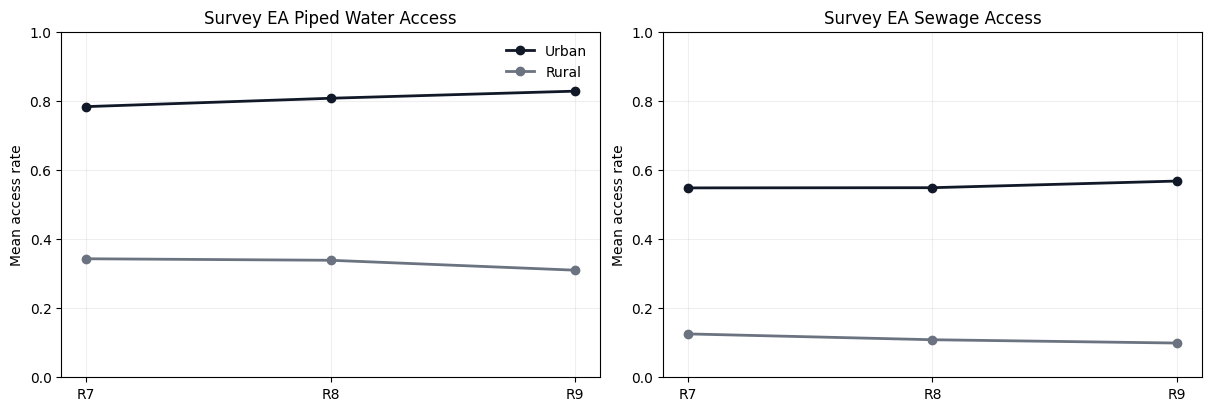

In [2]:
from IPython.display import display

display(survey_round_urban)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, value_col, title in zip(
    axes,
    ['piped_water', 'sewage'],
    ['Survey EA Piped Water Access', 'Survey EA Sewage Access'],
):
    for urbanicity, color in [('Urban', '#111827'), ('Rural', '#6b7280')]:
        subset = survey_round_urban[survey_round_urban['urbanicity'] == urbanicity].sort_values('round')
        ax.plot(subset['round'], subset[value_col], marker='o', linewidth=2, color=color, label=urbanicity)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Mean access rate')
    ax.grid(alpha=0.2)
axes[0].legend(frameon=False)
plt.show()



,round,country,ea_count,urban_share,piped_water_survey,piped_water_inference,piped_water_gap,sewage_survey,sewage_inference,sewage_gap,piped_water_tile_count,sewage_tile_count
16,R7,Mauritius,150,0.373333,1.000000,0.0,1.000000,0.486667,0.236583,0.250084,913,913
91,R9,Seychelles,147,1.000000,1.000000,0.0,1.000000,0.632653,0.318627,0.314026,204,204
84,R9,Mauritius,150,0.386667,0.993333,0.0,0.993333,0.480000,0.236583,0.243417,913,913
49,R8,Mauritius,142,0.380282,0.985915,0.0,0.985915,0.514085,0.236583,0.277502,913,913
59,R8,Tunisia,150,0.680000,0.966667,0.0,0.966667,0.726667,0.145612,0.581055,14937,14937
34,R8,Botswana,141,0.219858,0.946809,0.0,0.946809,0.546099,0.006261,0.539839,24917,24917
96,R9,Tunisia,148,0.682432,0.932432,0.0,0.932432,0.804054,0.145612,0.658442,14937,14937
27,R7,Tunisia,147,0.687075,0.904762,0.0,0.904762,0.751701,0.145612,0.606089,14937,14937
21,R7,Sao Tome and Principe,148,0.668919,0.898649,0.0,0.898649,0.256757,0.016529,0.240228,121,121
36,R8,Cabo Verde,146,0.712329,0.883562,0.0,0.883562,0.609589,0.021631,0.587958,601,601


,round,country,ea_count,urban_share,piped_water_survey,piped_water_inference,piped_water_gap,sewage_survey,sewage_inference,sewage_gap,piped_water_tile_count,sewage_tile_count
96,R9,Tunisia,148,0.682432,0.932432,0.0,0.932432,0.804054,0.145612,0.658442,14937,14937
37,R8,Cameroon,149,0.496644,0.657718,0.0,0.657718,0.624161,0.011425,0.612736,28358,28358
27,R7,Tunisia,147,0.687075,0.904762,0.0,0.904762,0.751701,0.145612,0.606089,14937,14937
36,R8,Cabo Verde,146,0.712329,0.883562,0.0,0.883562,0.609589,0.021631,0.587958,601,601
59,R8,Tunisia,150,0.680000,0.966667,0.0,0.966667,0.726667,0.145612,0.581055,14937,14937
88,R9,Nigeria,196,0.433673,0.372449,0.0,0.372449,0.591837,0.024955,0.566882,106912,106912
69,R9,Cameroon,148,0.533784,0.702703,0.0,0.702703,0.567568,0.011425,0.556142,28358,28358
34,R8,Botswana,141,0.219858,0.946809,0.0,0.946809,0.546099,0.006261,0.539839,24917,24917
18,R7,Namibia,222,0.662162,0.648649,0.0,0.648649,0.540541,0.018808,0.521733,23554,23554
22,R7,Senegal,198,0.525253,0.787879,0.0,0.787879,0.489899,0.006171,0.483728,17988,17988


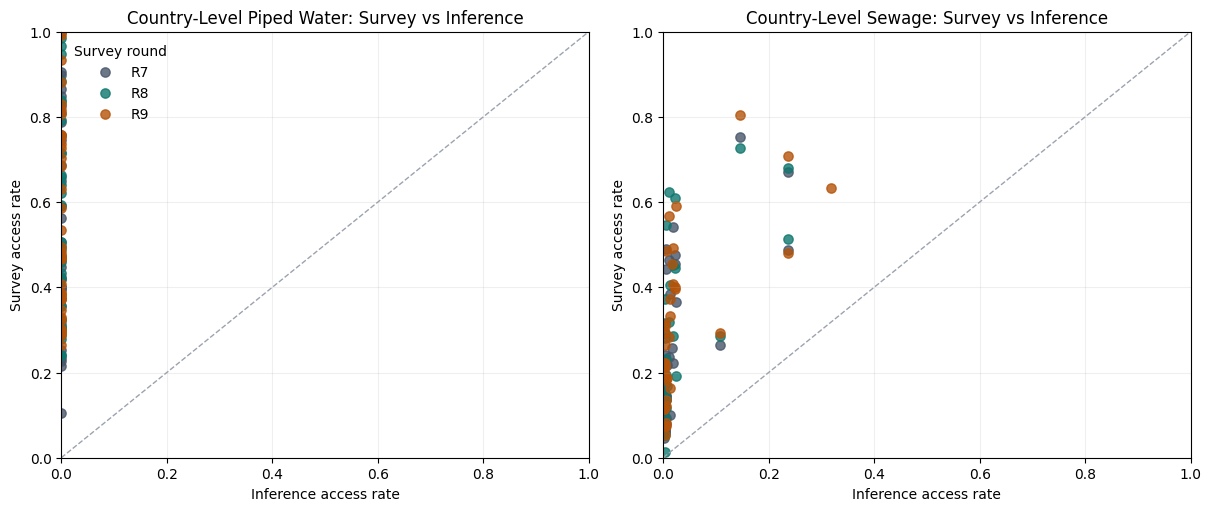

In [3]:
from IPython.display import display

display(
    comparison_view.sort_values('piped_water_gap', key=lambda series: series.abs(), ascending=False).head(12)
)
display(
    comparison_view.sort_values('sewage_gap', key=lambda series: series.abs(), ascending=False).head(12)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, service, title in zip(
    axes,
    ['piped_water', 'sewage'],
    ['Country-Level Piped Water: Survey vs Inference', 'Country-Level Sewage: Survey vs Inference'],
):
    survey_col = f'{service}_survey'
    inference_col = f'{service}_inference'
    limit = max(1.0, comparison[[survey_col, inference_col]].max().max())
    for round_name in round_order:
        subset = comparison[comparison['round'] == round_name]
        ax.scatter(
            subset[inference_col],
            subset[survey_col],
            s=45,
            alpha=0.8,
            color=round_colors[round_name],
            label=round_name,
        )
    ax.plot([0, limit], [0, limit], linestyle='--', linewidth=1, color='#9ca3af')
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_xlabel('Inference access rate')
    ax.set_ylabel('Survey access rate')
    ax.set_title(title)
    ax.grid(alpha=0.2)
axes[0].legend(title='Survey round', frameon=False)
plt.show()



,R8 - R7,R9 - R8,R9 - R7
country,,,
Lesotho,0.151936,0.044104,0.196039
Liberia,0.181709,0.014244,0.195953
Burkina Faso,-0.073333,0.229799,0.156465
Zambia,0.184885,-0.035385,0.149501
Mali,0.134228,-0.006711,0.127517
Namibia,0.066680,0.021158,0.087838
Sierra Leone,0.010115,0.075278,0.085393
Tanzania,0.054237,0.020373,0.074611
Uganda,0.070713,0.000094,0.070807


,R8 - R7,R9 - R8,R9 - R7
country,,,
Ghana,-0.160232,-0.077763,-0.237995
Sudan,-0.045369,-0.103990,-0.149359
Sao Tome and Principe,NaN,NaN,-0.146925
Botswana,0.080611,-0.220781,-0.140170
Niger,-0.046667,-0.086667,-0.133333
Madagascar,NaN,NaN,-0.107763
Togo,0.098720,-0.165563,-0.066843
Cameroon,-0.087248,0.044985,-0.042264
Benin,0.060000,-0.100000,-0.040000


,R8 - R7,R9 - R8,R9 - R7
country,,,
Gambia,0.034776,0.212824,0.247599
Nigeria,-0.173976,0.401115,0.227139
Sao Tome and Principe,NaN,NaN,0.198416
Gabon,0.065190,0.120000,0.185190
Liberia,0.255941,-0.095070,0.160870
Tanzania,0.077966,0.073229,0.151196
Cameroon,0.161074,-0.056594,0.104480
Zambia,0.120814,-0.027599,0.093215
Burkina Faso,-0.006667,0.074810,0.068143


,R8 - R7,R9 - R8,R9 - R7
country,,,
Senegal,-0.259130,-0.048337,-0.307467
Ghana,-0.030779,-0.047964,-0.078743
Uganda,-0.005905,-0.056020,-0.061924
Cabo Verde,0.155642,-0.209589,-0.053947
Namibia,-0.087986,0.040688,-0.047297
Kenya,-0.048978,0.018652,-0.030326
Mozambique,0.023691,-0.041868,-0.018177
Malawi,-0.053225,0.040533,-0.012692
Togo,0.048798,-0.059496,-0.010698


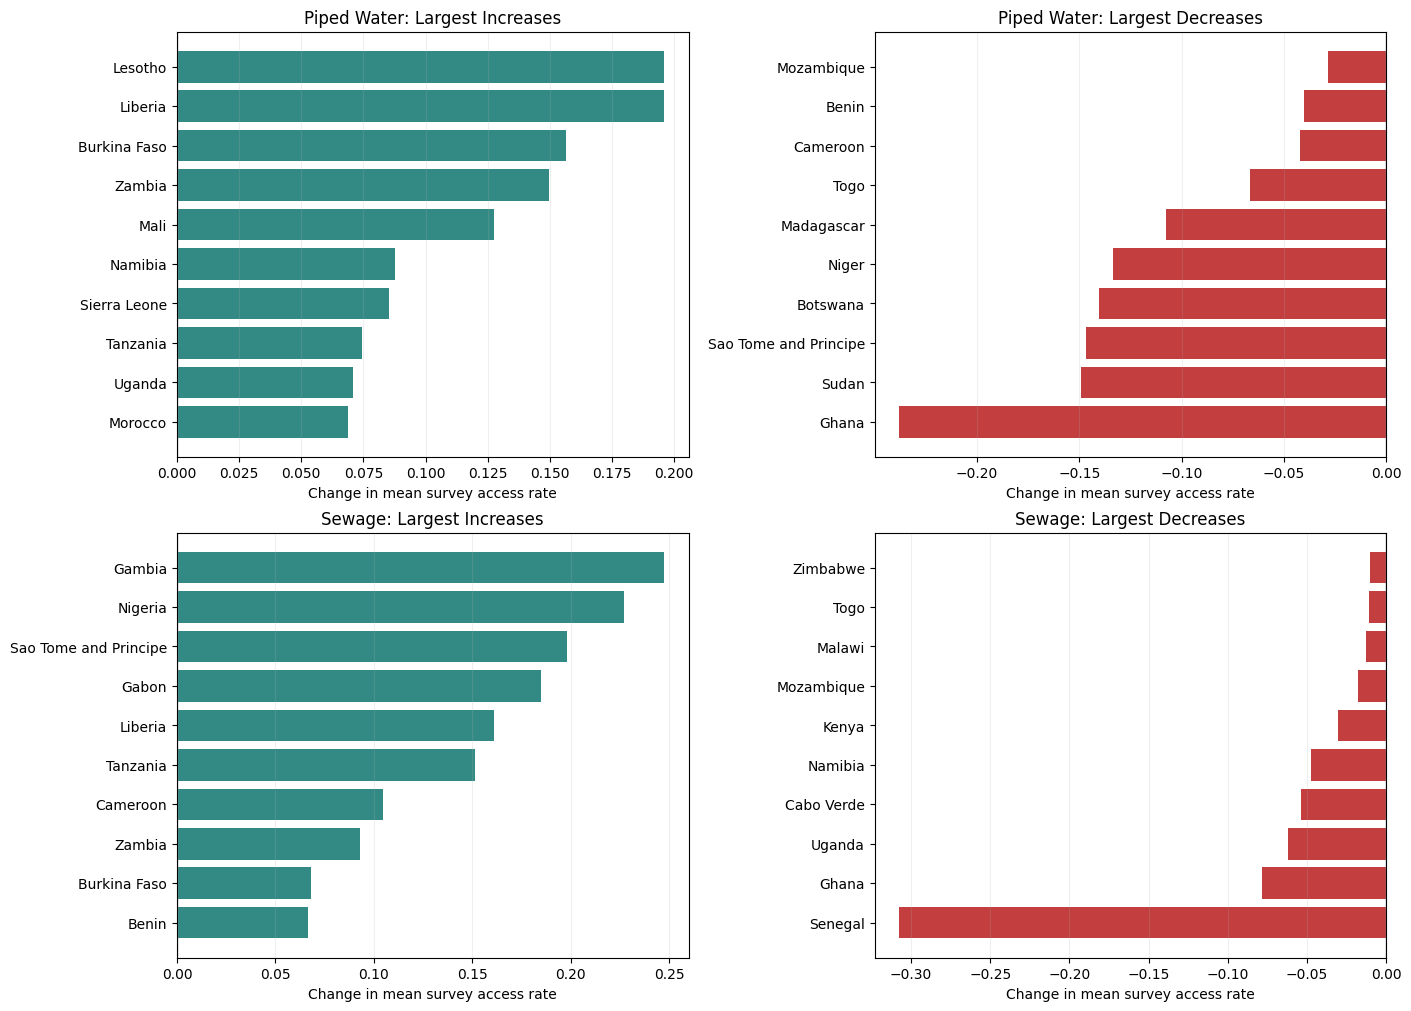

In [4]:
from IPython.display import display

piped_top_gain = piped_round_change.head(10)
piped_top_drop = piped_round_change.sort_values('R9 - R7').head(10)
sewage_top_gain = sewage_round_change.head(10)
sewage_top_drop = sewage_round_change.sort_values('R9 - R7').head(10)

display(piped_top_gain)
display(piped_top_drop)
display(sewage_top_gain)
display(sewage_top_drop)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
plot_specs = [
    (axes[0, 0], piped_top_gain.sort_values('R9 - R7'), 'R9 - R7', 'Piped Water: Largest Increases', '#0f766e'),
    (axes[0, 1], piped_top_drop.sort_values('R9 - R7'), 'R9 - R7', 'Piped Water: Largest Decreases', '#b91c1c'),
    (axes[1, 0], sewage_top_gain.sort_values('R9 - R7'), 'R9 - R7', 'Sewage: Largest Increases', '#0f766e'),
    (axes[1, 1], sewage_top_drop.sort_values('R9 - R7'), 'R9 - R7', 'Sewage: Largest Decreases', '#b91c1c'),
]
for ax, table, delta_col, title, color in plot_specs:
    ax.barh(table.index.astype(str), table[delta_col], color=color, alpha=0.85)
    ax.axvline(0, color='#94a3b8', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Change in mean survey access rate')
    ax.grid(axis='x', alpha=0.2)
plt.show()

# Optional next step:
# inferred_urbanicity = assign_inference_urbanicity_from_nearest_survey(
#     inference_predictions_analysis[['country', 'service', 'lat', 'lon', 'pred_class']].copy(),
#     survey_ea,
#     max_distance_km=25,
# )


In [5]:
# JMP comparison setup
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

jmp_summary_path = Path('/home/mila/e/echchabo/projects/SDG6-Tracker/data/inference_summary.csv')
jmp_summary = pd.read_csv(jmp_summary_path)

jmp_specs = {
    'piped_water': {
        'label': 'Piped Water vs JMP',
        'pred_col': 'Piped Water Access (%)',
        'gt_col': 'Piped (JMP)',
        'coverage_col': 'Piped Water Coverage (%)',
        'matched_pop_col': 'Piped Water Matched Population',
        'color': '#c2410c',
    },
    'safely_managed': {
        'label': 'Sewage vs Safely managed',
        'pred_col': 'Sewage Access (%)',
        'gt_col': 'Safely managed',
        'coverage_col': 'Sewage Coverage (%)',
        'matched_pop_col': 'Sewage Matched Population',
        'color': '#0369a1',
    },
}

def build_jmp_comparison(summary_df, spec):
    comp = summary_df[
        ['Country', spec['pred_col'], spec['gt_col'], spec['coverage_col'], spec['matched_pop_col'], 'Total Population']
    ].copy()
    comp = comp.rename(
        columns={
            spec['pred_col']: 'predicted',
            spec['gt_col']: 'ground_truth',
            spec['coverage_col']: 'coverage',
            spec['matched_pop_col']: 'matched_population',
            'Total Population': 'total_population',
        }
    )
    for col in ['predicted', 'ground_truth', 'coverage', 'matched_population', 'total_population']:
        comp[col] = pd.to_numeric(comp[col], errors='coerce')
    comp = comp.dropna(subset=['predicted', 'ground_truth']).copy()
    comp['residual'] = comp['predicted'] - comp['ground_truth']
    comp['abs_error'] = comp['residual'].abs()
    comp['mean_level'] = 0.5 * (comp['predicted'] + comp['ground_truth'])
    comp['rank_predicted'] = comp['predicted'].rank(ascending=False, method='min')
    comp['rank_ground_truth'] = comp['ground_truth'].rank(ascending=False, method='min')
    comp['rank_gap'] = comp['rank_predicted'] - comp['rank_ground_truth']
    return comp.sort_values('abs_error', ascending=False).reset_index(drop=True)

jmp_comparisons = {key: build_jmp_comparison(jmp_summary, spec) for key, spec in jmp_specs.items()}

jmp_metrics = pd.DataFrame([
    {
        'service': spec['label'],
        'n_countries': len(comp),
        'missing_ground_truth': int(jmp_summary[spec['gt_col']].isna().sum()),
        'mae': comp['abs_error'].mean(),
        'rmse': np.sqrt((comp['residual'] ** 2).mean()),
        'bias': comp['residual'].mean(),
        'pearson_r': comp['predicted'].corr(comp['ground_truth']),
        'spearman_r': comp['predicted'].corr(comp['ground_truth'], method='spearman'),
    }
    for key, spec in jmp_specs.items()
    for comp in [jmp_comparisons[key]]
])



,service,n_countries,missing_ground_truth,mae,rmse,bias,pearson_r,spearman_r
0,Piped Water vs JMP,48,3,14.345208,18.219852,-9.287708,0.817678,0.763786
1,Sewage vs Safely managed,27,24,14.452449,19.300995,-11.094488,0.703689,0.395604


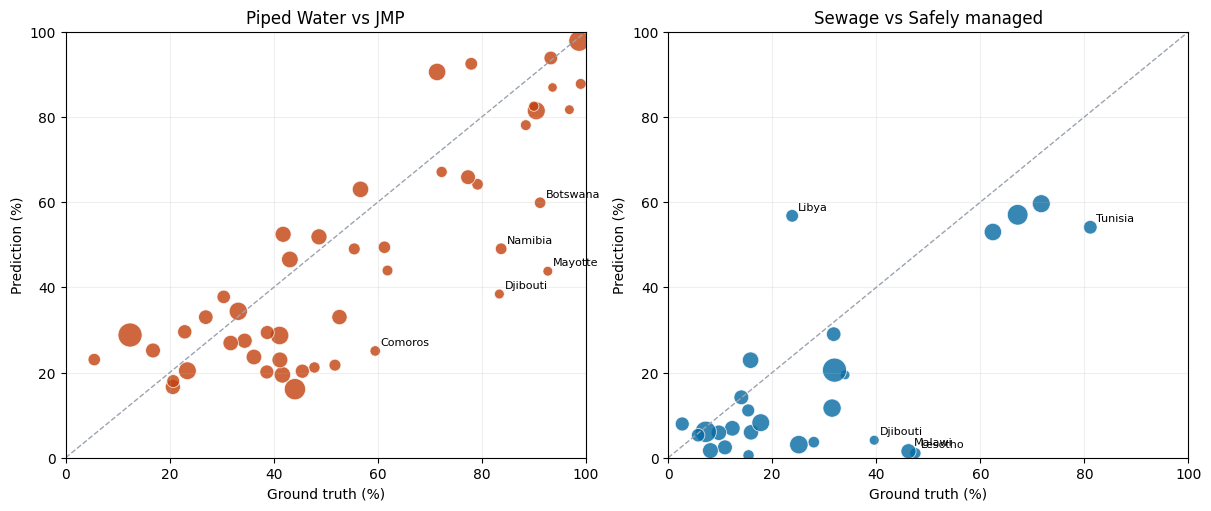

In [6]:
# JMP scatter comparisons
from IPython.display import display

display(jmp_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, key in zip(axes, ['piped_water', 'safely_managed']):
    spec = jmp_specs[key]
    comp = jmp_comparisons[key]
    sizes = 40 + 260 * np.sqrt(comp['matched_population'] / comp['matched_population'].max())
    ax.scatter(
        comp['ground_truth'],
        comp['predicted'],
        s=sizes,
        alpha=0.8,
        color=spec['color'],
        edgecolor='white',
        linewidth=0.6,
    )
    limit = max(100, comp[['ground_truth', 'predicted']].max().max())
    ax.plot([0, limit], [0, limit], linestyle='--', linewidth=1, color='#9ca3af')
    for _, row in comp.head(5).iterrows():
        ax.annotate(row['Country'], (row['ground_truth'], row['predicted']), fontsize=8, xytext=(4, 4), textcoords='offset points')
    ax.set_title(spec['label'])
    ax.set_xlabel('Ground truth (%)')
    ax.set_ylabel('Prediction (%)')
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.grid(alpha=0.2)
plt.show()



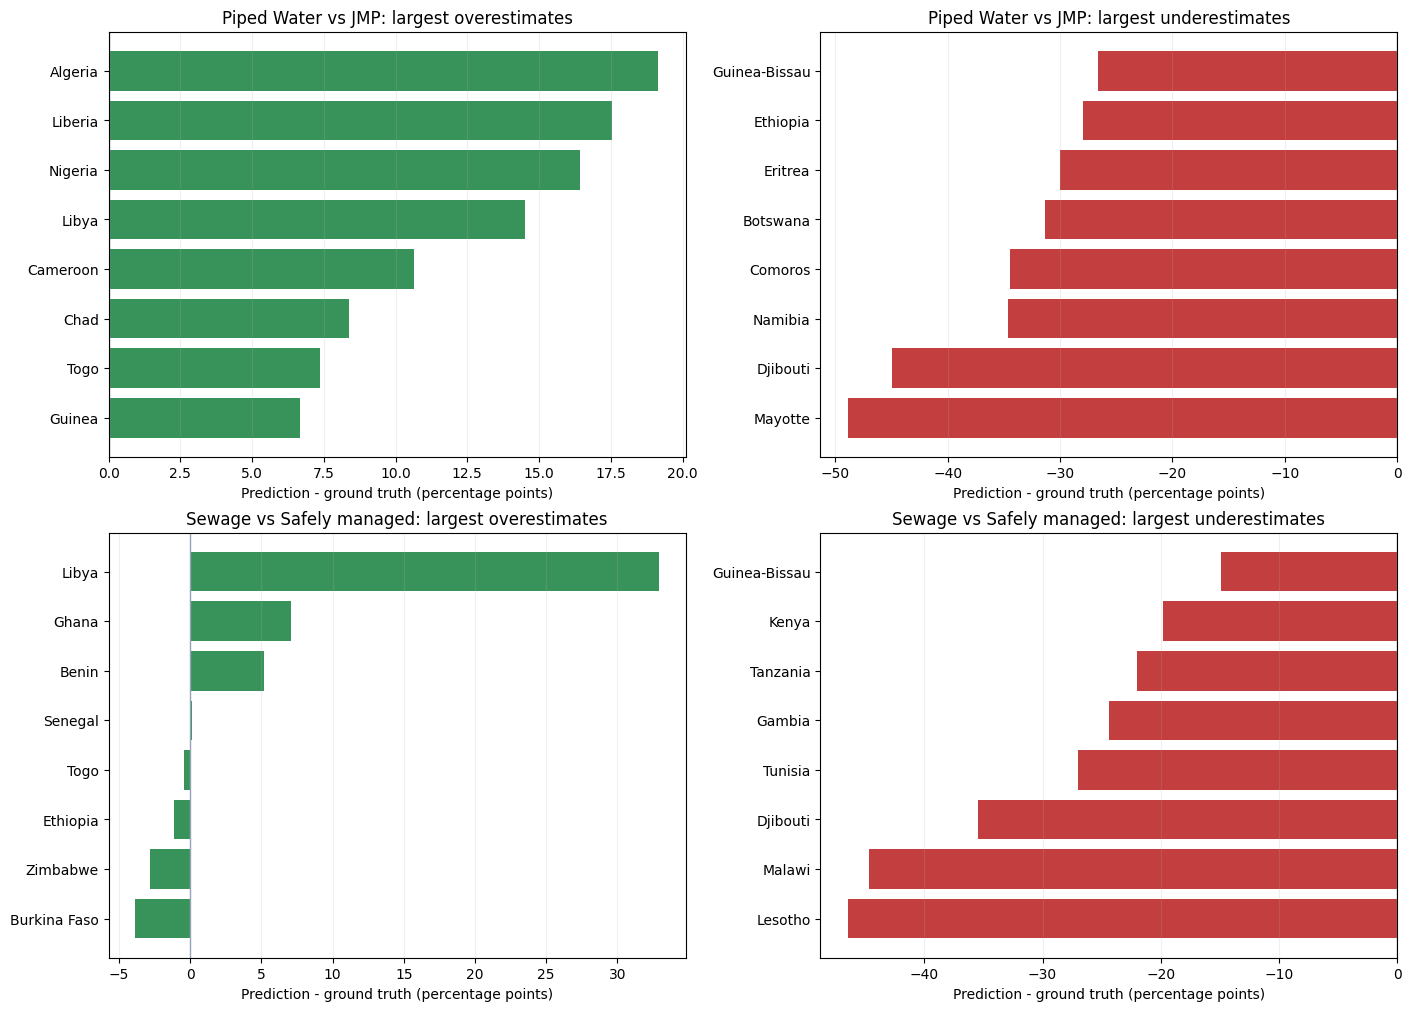

In [7]:
# JMP residual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
plot_specs = [
    ('piped_water', axes[0, 0], 'over'),
    ('piped_water', axes[0, 1], 'under'),
    ('safely_managed', axes[1, 0], 'over'),
    ('safely_managed', axes[1, 1], 'under'),
]
for key, ax, mode in plot_specs:
    spec = jmp_specs[key]
    comp = jmp_comparisons[key]
    if mode == 'over':
        table = comp.sort_values('residual', ascending=False).head(8).sort_values('residual')
        title = f"{spec['label']}: largest overestimates"
        color = '#15803d'
    else:
        table = comp.sort_values('residual').head(8)
        title = f"{spec['label']}: largest underestimates"
        color = '#b91c1c'
    ax.barh(table['Country'], table['residual'], color=color, alpha=0.85)
    ax.axvline(0, color='#94a3b8', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Prediction - ground truth (percentage points)')
    ax.grid(axis='x', alpha=0.2)
plt.show()



,Country,predicted,ground_truth,rank_predicted,rank_ground_truth,rank_gap
6,Ethiopia,16.09,44.07,48.0,28.0,20.0
0,Mayotte,43.78,92.67,23.0,6.0,17.0
5,Eritrea,21.73,51.76,40.0,24.0,16.0
3,Comoros,25.06,59.50,36.0,20.0,16.0
8,Rwanda,20.31,45.49,43.0,27.0,16.0
16,Nigeria,28.80,12.38,31.0,47.0,-16.0
31,Togo,37.75,30.38,25.0,40.0,-15.0
7,Guinea-Bissau,21.18,47.81,41.0,26.0,15.0
34,Guinea,29.55,22.89,29.0,43.0,-14.0
25,Cameroon,52.44,41.80,16.0,30.0,-14.0


,Country,predicted,ground_truth,rank_predicted,rank_ground_truth,rank_gap
0,Lesotho,1.05,47.516246,26.0,5.0,21.0
1,Malawi,1.52,46.190810,25.0,6.0,19.0
2,Djibouti,4.11,39.601205,20.0,7.0,13.0
20,Benin,7.92,2.701276,14.0,27.0,-13.0
3,Libya,56.78,23.830540,3.0,14.0,-11.0
17,Ghana,22.89,15.834102,7.0,17.0,-10.0
26,Senegal,14.17,14.061602,10.0,20.0,-10.0
24,Ethiopia,6.08,7.219802,16.0,25.0,-9.0
5,Gambia,3.65,27.986058,21.0,12.0,9.0
6,Tanzania,3.07,25.114795,22.0,13.0,9.0


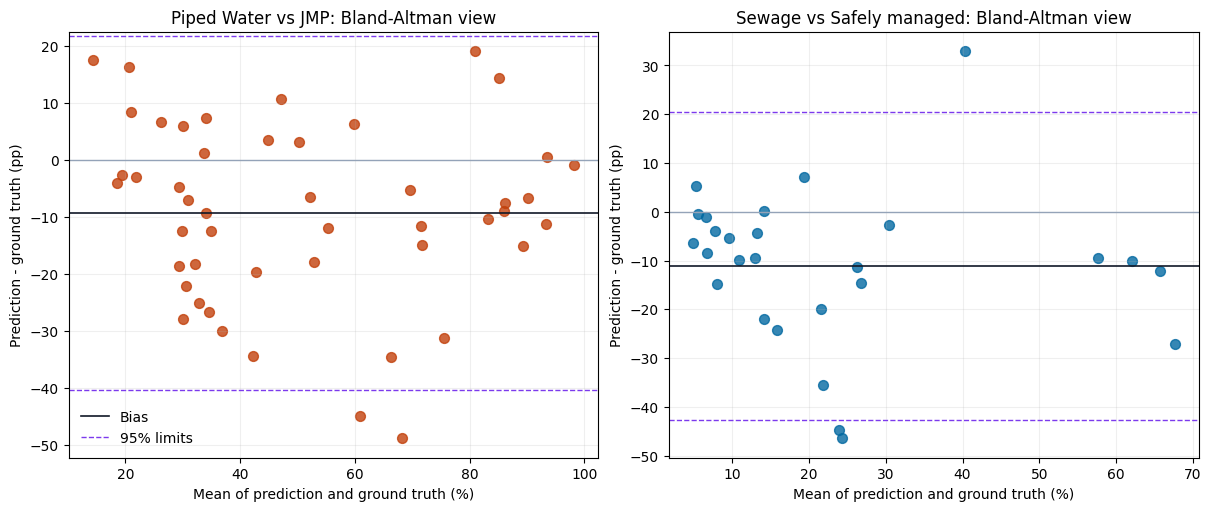

In [8]:
# JMP rank and Bland-Altman diagnostics
from IPython.display import display

piped_rank_gap = jmp_comparisons['piped_water'].reindex(
    jmp_comparisons['piped_water']['rank_gap'].abs().sort_values(ascending=False).index
)[['Country', 'predicted', 'ground_truth', 'rank_predicted', 'rank_ground_truth', 'rank_gap']].head(10)

safely_managed_rank_gap = jmp_comparisons['safely_managed'].reindex(
    jmp_comparisons['safely_managed']['rank_gap'].abs().sort_values(ascending=False).index
)[['Country', 'predicted', 'ground_truth', 'rank_predicted', 'rank_ground_truth', 'rank_gap']].head(10)

display(piped_rank_gap)
display(safely_managed_rank_gap)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, key in zip(axes, ['piped_water', 'safely_managed']):
    spec = jmp_specs[key]
    comp = jmp_comparisons[key]
    bias = comp['residual'].mean()
    sd = comp['residual'].std(ddof=1)
    ax.scatter(comp['mean_level'], comp['residual'], s=50, alpha=0.8, color=spec['color'])
    ax.axhline(bias, color='#111827', linewidth=1.2, label='Bias')
    ax.axhline(bias + 1.96 * sd, color='#7c3aed', linewidth=1, linestyle='--', label='95% limits')
    ax.axhline(bias - 1.96 * sd, color='#7c3aed', linewidth=1, linestyle='--')
    ax.axhline(0, color='#94a3b8', linewidth=1)
    ax.set_title(f"{spec['label']}: Bland-Altman view")
    ax.set_xlabel('Mean of prediction and ground truth (%)')
    ax.set_ylabel('Prediction - ground truth (pp)')
    ax.grid(alpha=0.2)
axes[0].legend(frameon=False)
plt.show()

